## **# Importing Datasets**




In [ ]:
# extracting the compressed Dataset
from zipfile import ZipFile
dataset = '/content/Aadhar Detection.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls

'aadhaar_card_data(414).json'  'Aadhar Detection.zip'
'Aadhar Detection'	        sample_data


## **Install and Import Dependencies**

In [ ]:
!pip install python-Levenshtein

In [ ]:
!pip install openbharatocr

In [ ]:
import openbharatocr
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import os
import re
import networkx as nx

## **Read in single Image & Draw Results**



In [ ]:
Image_path = '/content/Aadhar Detection/aadhar(1593)/3f39d5b5c5ac419d80ddf02e768fbfca_EIEPM9951A1046444AADHAAR-CARD-120221031_102950_jpg.rf.a0b04e21f641bfa8f51c91ab090d3de3.jpg'
front_result = openbharatocr.front_aadhaar(Image_path)
front_result

{'Full Name': 'Shuvam Mukherjee',
 'Date/Year of Birth': '14/06/1996',
 'Gender': 'Male',
 'Aadhaar Number': '4747 3054 6946'}

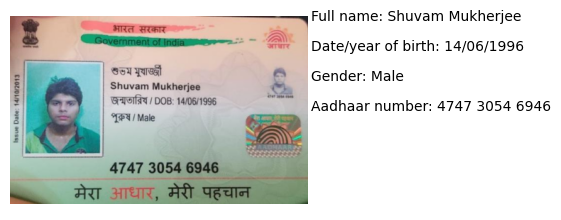

In [ ]:
img = cv2.imread(Image_path)

# Resize image (scale down)
img = cv2.resize(img, None, fx=0.7, fy=0.7)  # reduce to 70%

# Extract Aadhaar details
front_result = openbharatocr.front_aadhaar(Image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(
    1, 2,
    figsize=(4,2),
    gridspec_kw={'width_ratios': [3, 1]}
)

# Aadhaar image
ax[0].imshow(img_rgb)
ax[0].axis("off")

# Text panel
ax[1].axis("off")

y = 1.0
for key, value in front_result.items():
    ax[1].text(0.0, y, f"{key.capitalize()}: {value}", fontsize=10, va='top')
    y -= 0.15

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.02)

plt.show()

### **Troubled Images**

In [ ]:
Image_path = '/content/Aadhar Detection/aadhar(1593)/3b5c437c1556437bb3ce7d76f84f6b56_AOKPN6124J1035985AADHAAR-CARD-120220926_114315_jpg.rf.d1140d6e2dc920a85a718ea96de0cd5f.jpg'
front_result = openbharatocr.front_aadhaar(Image_path)
front_result

{'Full Name': 'Governmant',
 'Date/Year of Birth': '11/06/1987',
 'Gender': 'Male',
 'Aadhaar Number': ''}

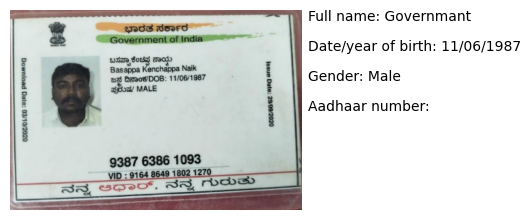

In [ ]:
img = cv2.imread(Image_path)

# Resize image (scale down)
img = cv2.resize(img, None, fx=0.7, fy=0.7)  # reduce to 70%

# Extract Aadhaar details
front_result = openbharatocr.front_aadhaar(Image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(
    1, 2,
    figsize=(4,2),
    gridspec_kw={'width_ratios': [3, 1]}
)

# Aadhaar image
ax[0].imshow(img_rgb)
ax[0].axis("off")

# Text panel
ax[1].axis("off")

y = 1.0
for key, value in front_result.items():
    ax[1].text(0.0, y, f"{key.capitalize()}: {value}", fontsize=10, va='top')
    y -= 0.15

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.02)

plt.show()

**Reading all Images & Draw Results**



In [ ]:
folder_path = "/content/Aadhar Detection/aadhar(1593)"

all_records = []

for file in os.listdir(folder_path):

    if file.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(folder_path, file)

        try:
            result = openbharatocr.front_aadhaar(image_path)

            record = {
                "name": result.get("Full Name"),
                "dob": result.get("Date/Year of Birth"),
                "gender": result.get("Gender"),
                "aadhaar_number": result.get("Aadhaar Number")
            }

            all_records.append(record)

        except Exception as e:
            print(f"Error processing {file}: {e}")


# Print extracted details
limit = 10
print("Showing first", limit, "records")
for rec in all_records:
    for key, value in rec.items():
        if key != "file_name":
            print(f"{key}: {value}")
    print()

Showing first 10 records
name: Shashi Devi
Lin
dob: 01/01/1258
gender: Other
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: Ragtavaroaty
dob: 0012
gender: Other
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: Amit Kabra
dob: 16/11/1995
gender: Male
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: 
dob: 
gender: Other
aadhaar_number: 

name: Scone
dob: 
gender: Other
aadhaar_number: 

name: Ruy
dob: 3253
gender: Other
aadhaar_number: 

name: Conds
dob: 26/08/1958
gender: Other
aadhaar_number: 8214 7687 9917

name: Madero
Sutarlya Bhadresnbhat
Gordnnbhal
dob: 14/12/1980
gender: Male
aadhaar_number: 3930 7954 9354

name: Erieeomecrc
dob: 3943
gender: Other
aadhaar_number: 3843 5941 9959

name: Vimala
dob: 08/03/1972
gender: Female
aadhaar_number: 8735 8868 1911

name: Maheshwaran
dob: 16/08/198

In [ ]:
print(len(all_records))

1593


### **Data Cleaning**

In [ ]:
missing_aadhaar = []
gender_other = []
dob_four_digit = []

for rec in all_records:

    # 1️⃣ Missing Aadhaar number
    if rec["aadhaar_number"] == "" or rec["aadhaar_number"] is None:
        missing_aadhaar.append(rec)

    # 2️⃣ Gender = Other
    if rec["gender"] == "Other":
        gender_other.append(rec)

    # 3️⃣ DOB only 4 digits
    if rec["dob"] and re.fullmatch(r"\d{4}", rec["dob"]):
        dob_four_digit.append(rec)

In [ ]:
print("\n--- Records with Missing Aadhaar Number --- Count:", len(missing_aadhaar))
print("\n--- Records with Gender = Other ---  Count:", len(gender_other))
print("\n--- Records with 4-digit DOB --- Count:", len(dob_four_digit))


--- Records with Missing Aadhaar Number --- Count: 1109

--- Records with Gender = Other ---  Count: 1272

--- Records with 4-digit DOB --- Count: 311


In [ ]:
# print("\n--- Records with Missing Aadhaar Number --- Count:", len(missing_aadhaar))
# print()
# for r in missing_aadhaar:
#     print("File:", r["file_name"])
#     print(f'name: {r["name"]}, dob: {r["dob"]}, gender: {r["gender"]}, aadhaar_number: {r["aadhaar_number"]}')
#     print()

# print("\n--- Records with Gender = Other ---  Count:", len(gender_other))
# print()
# for r in gender_other:
#     print("File:", r["file_name"])
#     print(f'name: {r["name"]}, dob: {r["dob"]}, gender: {r["gender"]}, aadhaar_number: {r["aadhaar_number"]}')
#     print()

# print("\n--- Records with 4-digit DOB --- Count:", len(dob_four_digit))
# print()
# for r in dob_four_digit:
#     print("File:", r["file_name"])
#     print(f'name: {r["name"]}, dob: {r["dob"]}, gender: {r["gender"]}, aadhaar_number: {r["aadhaar_number"]}')
#     print()

**Since OCR has a lot of missing records we are training the model on the records(stored in json file) extracted from the samples using CLAUDE AI**

In [ ]:
import json

# Open the JSON file and load its content
with open('/content/aadhaar_card_data(414).json', 'r') as f:
    all_records = json.load(f)

print(f"Total Aadhaar records loaded: {len(all_records)}")
print("First record:", all_records[0])

Total Aadhaar records loaded: 414
First record: {'Full Name': 'Romil Singhal', 'Date/Year of Birth': '13/05/1976', 'Gender': 'Male', 'Aadhaar Number': '2489 5284 6046'}


In [ ]:
# Print last 5 records
for i, record in enumerate(all_records[-5:], 1):
    record_no_file = {k: v for k, v in record.items()}
    print(f"Record {i}: {record_no_file}")

Record 1: {'Full Name': 'Mohan Pandit', 'Date/Year of Birth': '05/09/1966', 'Gender': 'Male', 'Aadhaar Number': '8120 0153 0409'}
Record 2: {'Full Name': 'Jayant Vyas', 'Date/Year of Birth': '25/01/2001', 'Gender': 'Male', 'Aadhaar Number': '9719 6881 4983'}
Record 3: {'Full Name': 'Gala Jigna Hiten', 'Date/Year of Birth': '26/06/1975', 'Gender': 'Female', 'Aadhaar Number': '6600 5139 7344'}
Record 4: {'Full Name': 'Soni Dwarkalal', 'Date/Year of Birth': '1941', 'Gender': 'Male', 'Aadhaar Number': '6130 4558 8299'}
Record 5: {'Full Name': 'Subasini Amma', 'Date/Year of Birth': '23/06/1984', 'Gender': 'Female', 'Aadhaar Number': '8679 4310 7206'}


In [ ]:
missing_Full_Name = []
missing_aadhaar = []
gender_other = []
dob_four_digit = []

for rec in all_records:

    # 1️ Missing Aadhaar number
    if rec["Aadhaar Number"] == "" or rec["Aadhaar Number"] is None:
        missing_aadhaar.append(rec)

    # 2️ Gender = Other
    if rec["Gender"] == "Other":
        gender_other.append(rec)

    # 3️ DOB only 4 digits
    if rec["Date/Year of Birth"] and re.fullmatch(r"\d{4}", rec["Date/Year of Birth"]):
        dob_four_digit.append(rec)

    # 4 Missing Full name
    if rec["Full Name"] and re.fullmatch(r"\d{4}", rec["Full Name"]):
        missing_Full_Name.append(rec)

## **Visualizing Network graph for any similar nodes**

In [ ]:
from difflib import SequenceMatcher
import networkx as nx
import matplotlib.pyplot as plt

# Function to compute similarity
def ratio(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Clean Aadhaar function
def clean_aadhaar(p):
    if not p:
        return ""
    return p.replace(" ", "").strip()

# Initialize graph
G = nx.Graph()

# Add nodes
for i, rec in enumerate(all_records):
    G.add_node(i,
               name=rec.get("Full Name"),
               dob=rec.get("Date/Year of Birth"),
               gender=rec.get("Gender"),
               aadhaar=rec.get("Aadhaar Number")
              )

# Create edges based on HIGH similarity only
for i in range(len(all_records)):
    for j in range(i+1, len(all_records)):
        r1 = all_records[i]
        r2 = all_records[j]
        reasons = []

        #  HIGH SIGNAL: Exact Aadhaar match
        a1 = clean_aadhaar(r1.get("Aadhaar Number"))
        a2 = clean_aadhaar(r2.get("Aadhaar Number"))
        if a1 and a1 == a2:
            reasons.append("same_aadhaar")

        #  HIGH SIGNAL: Exact Name + DOB match
        if (r1.get("Full Name") and r2.get("Full Name") and
            r1.get("Date/Year of Birth") and r2.get("Date/Year of Birth")):
            if (r1["Full Name"].lower().strip() == r2["Full Name"].lower().strip() and
                r1["Date/Year of Birth"] == r2["Date/Year of Birth"]):
                reasons.append("name_dob_match")

        #  HIGH SIGNAL: Very high name similarity (>= 0.85) AND same DOB
        if r1.get("Full Name") and r2.get("Full Name"):
            sim = ratio(r1["Full Name"].lower(), r2["Full Name"].lower())
            if sim >= 0.85 and r1.get("Date/Year of Birth") == r2.get("Date/Year of Birth"):
                reasons.append("high_name_sim_same_dob")

        # Add edge ONLY if a high-confidence reason exists
        if reasons:
            G.add_edge(i, j, reason=",".join(reasons))

print("Graph created with nodes:", G.number_of_nodes(), "and edges:", G.number_of_edges())

# Node colors based on degree
node_colors = []
for node in G.nodes():
    deg = G.degree[node]
    if deg >= 2:
        node_colors.append("red")       # suspicious cluster
    elif deg == 1:
        node_colors.append("orange")    # possible link
    else:
        node_colors.append("skyblue")   # isolated / clean


Graph created with nodes: 414 and edges: 84


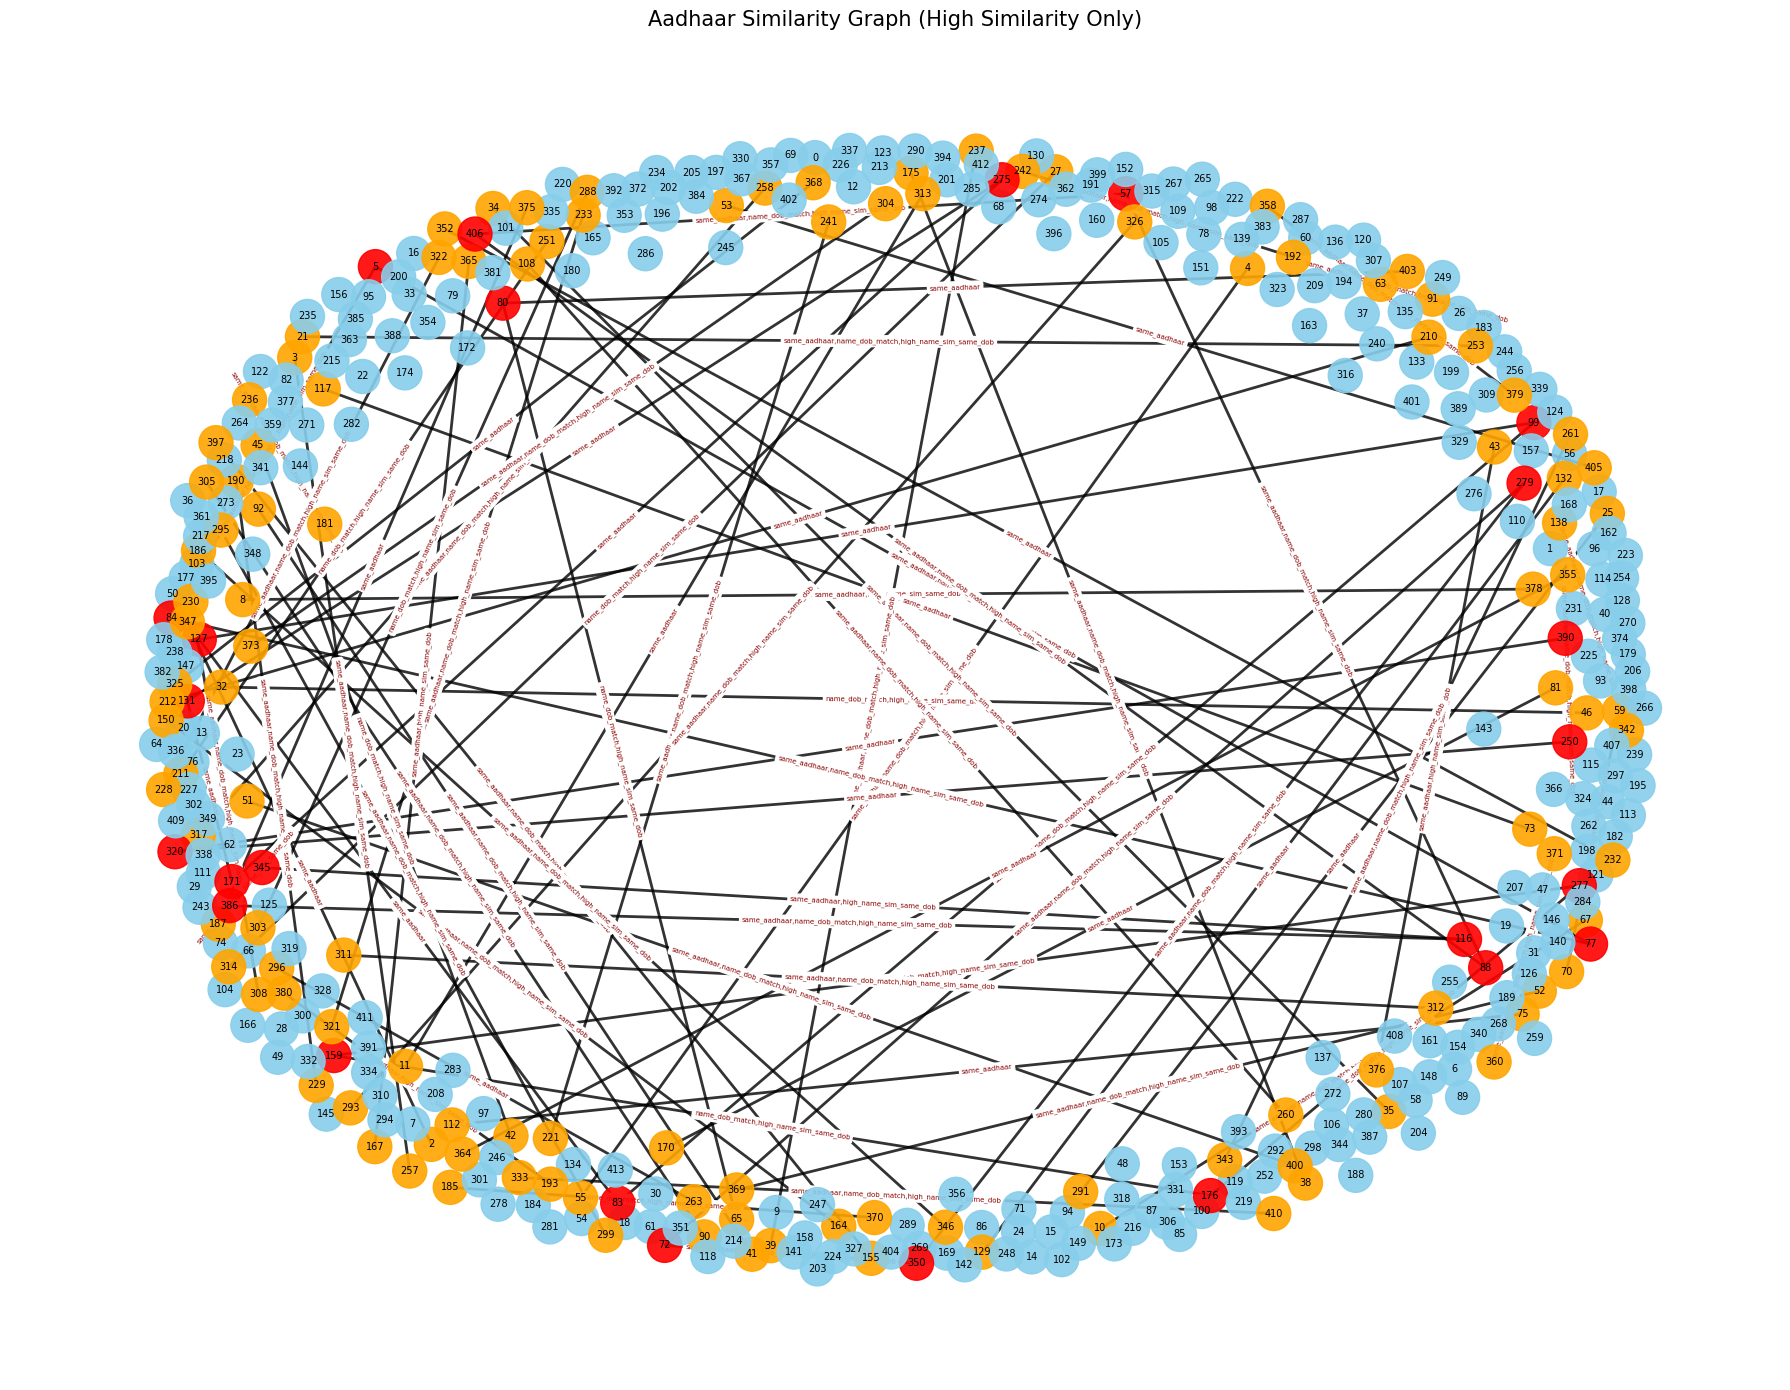

Number of edges: 84


In [ ]:
# Draw
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, k=3.0, seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color="black", width=2.0, alpha=0.8)  # darker, thicker edges
nx.draw_networkx_labels(G, pos, font_size=7, font_color="black")

# Edge labels showing reason
edge_labels = nx.get_edge_attributes(G, "reason")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5, font_color="darkred")

plt.title("Aadhaar Similarity Graph (High Similarity Only)", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Number of edges:", G.number_of_edges())

In [ ]:
print("Number of edges:", G.number_of_edges())

Number of edges: 84


## **Training the GNN model**

**Install libraries**

In [ ]:
!pip install sentence-transformers torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00


In [ ]:
!pip install torch-geometric

**Import libraries**

In [ ]:
import numpy as np
import torch
import networkx as nx
import torch.nn.functional as F

from sentence_transformers import SentenceTransformer
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler

In [ ]:
data = from_networkx(G)

In [ ]:
#Convert names to embeddings
model_embed = SentenceTransformer("all-MiniLM-L6-v2")
names = [rec["Full Name"] if rec["Full Name"] else "" for rec in all_records]
name_vectors = model_embed.encode(names)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Extract numeric features
numeric_features = []

for rec in all_records:

    # Gender encoding
    gender_map = {"Male":0, "Female":1, "Other":2}
    gender = gender_map.get(rec.get("Gender"), 3)

    # DOB extraction
    day = 0
    month = 0
    year = 0

    dob = rec.get("Date/Year of Birth", "")

    if dob and "/" in dob:
        parts = dob.split("/")

        if len(parts) == 3:
            day = int(parts[0])
            month = int(parts[1])
            year = int(parts[2])

        elif len(parts) == 2:  # case like 05/1966
            month = int(parts[0])
            year = int(parts[1])

    elif dob and len(dob) == 4:
        year = int(dob)

    # Aadhaar digits
    aadhaar_digits = [0] * 12

    aadhaar = rec.get("Aadhaar Number", "")

    if aadhaar:
        a = aadhaar.replace(" ", "")

        # Only accept Aadhaar if it is purely digits
        if a.isdigit() and len(a) == 12:
            aadhaar_digits = [int(d) for d in a]

    numeric_features.append(
        [gender, day, month, year] + aadhaar_digits
    )

In [ ]:
#combine features

numeric_features = np.array(numeric_features)

features = np.concatenate(
    [name_vectors , numeric_features],
    axis=1
)

In [ ]:
#Normalise features
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [ ]:
#Convert to tensor
X = torch.tensor(features , dtype=torch.float)

In [ ]:
#Convert NetworkX graph → PyTorch Geometric
data = from_networkx(G)
data.x = X

I used SentenceTransformers with the all-MiniLM-L6-v2 model. That model produces: 384 Dimensions so   
name_vector → 384 features ,  
gender = 1  
day = 1  
month = 1   
year = 1   
aadhaar_digits = 12   
[gender, day, month, year] + aadhaar_digits = 4 + 12 = 16 features,  
name embedding = 384   
numeric features = 16    
384 + 16 = 400

In [ ]:
# Define Gnn model
class GNN(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(400 , 128)
        self.conv2 = GCNConv(128 , 64)

    def forward(self , x , edge_index):

        x = self.conv1(x , edge_index)
        x = F.relu(x)

        x = self.conv2(x , edge_index)

        return x

In [ ]:
#Train the model
model = GNN()

optimizer = torch.optim.Adam(model.parameters() , lr=0.01)

for epoch in range(200):

    model.train()

    optimizer.zero_grad()

    out = model(data.x , data.edge_index)

    loss = torch.mean(out**2)

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:",epoch,"Loss:",loss.item())

Epoch: 0 Loss: 0.9882588386535645
Epoch: 20 Loss: 0.021827438846230507
Epoch: 40 Loss: 0.002952461363747716
Epoch: 60 Loss: 0.00063211505766958
Epoch: 80 Loss: 0.00022598756186198443
Epoch: 100 Loss: 0.00012126942601753399
Epoch: 120 Loss: 7.936986366985366e-05
Epoch: 140 Loss: 5.667998630087823e-05
Epoch: 160 Loss: 4.232585706631653e-05
Epoch: 180 Loss: 3.261575329815969e-05


In [ ]:
#compute anomaly scores
model.eval()

with torch.no_grad():

    embeddings = model(data.x , data.edge_index)

scores = torch.norm(embeddings , dim=1)

for i , s in enumerate(scores):
    print("Record",i,"Anomaly Score:",float(s))

Record 0 Anomaly Score: 0.008014357648789883
Record 1 Anomaly Score: 0.036318834871053696
Record 2 Anomaly Score: 0.015113762579858303
Record 3 Anomaly Score: 0.024582713842391968
Record 4 Anomaly Score: 0.016398966312408447
Record 5 Anomaly Score: 0.010407909750938416
Record 6 Anomaly Score: 0.05981124937534332
Record 7 Anomaly Score: 0.010089372284710407
Record 8 Anomaly Score: 0.015620483085513115
Record 9 Anomaly Score: 0.009885975159704685
Record 10 Anomaly Score: 0.015253715217113495
Record 11 Anomaly Score: 0.02378814108669758
Record 12 Anomaly Score: 0.0740099623799324
Record 13 Anomaly Score: 0.06453520804643631
Record 14 Anomaly Score: 0.03433733433485031
Record 15 Anomaly Score: 0.04807049036026001
Record 16 Anomaly Score: 0.038353580981492996
Record 17 Anomaly Score: 0.03888804465532303
Record 18 Anomaly Score: 0.009645761922001839
Record 19 Anomaly Score: 0.06476344168186188
Record 20 Anomaly Score: 0.06332423537969589
Record 21 Anomaly Score: 0.017808476462960243
Record 2

In [ ]:
#Save the trained model
torch.save(model.state_dict(),"aadhaar_gnn_model.pth")

In [ ]:
#load the model
model.load_state_dict(torch.load("aadhaar_gnn_model.pth"))

<All keys matched successfully>

### **Testing on a Single sample**

In [ ]:
# Select one Aadhaar record from the dataset
record_index = 0
rec = all_records[record_index]
print("Testing record:")

Testing record:


In [ ]:
# In general how we should put threshold
scores_np = scores.numpy()
print("Max score in training:", scores_np.max())
print("Mean score:", scores_np.mean())
print("Std:", scores_np.std())
threshold = scores_np.mean() + 3*scores_np.std()
print(threshold)

Max score in training: 0.117182486
Mean score: 0.034160525
Std: 0.0219606
0.1000423226505518


In [ ]:
# Extract numeric features (same logic as training)
def extract_numeric_features(rec):
    gender_map = {"Male":0, "Female":1, "Other":2}
    gender = gender_map.get(rec.get("Gender"), 3)
    day, month, year = 0, 0, 0
    dob = rec.get("Date/Year of Birth")

    if dob and "/" in dob:
        parts = dob.split("/")
        if len(parts) == 3:
            day, month, year = map(int, parts)
    elif dob and len(dob) == 4:
        year = int(dob)

    aadhaar_digits = [0]*12
    if rec.get("Aadhaar Number"):
        a = rec["Aadhaar Number"].replace(" ", "")
        if len(a) == 12:
            aadhaar_digits = [int(d) for d in a]

    numeric = [gender, day, month, year] + aadhaar_digits
    return np.array(numeric)

# Convert name → vector using trained vectorizer
model_embed = SentenceTransformer("all-MiniLM-L6-v2")
names = [rec.get("Full Name", "")]
name_vector = model_embed.encode(names)

# Extract numeric feature vector
numeric = extract_numeric_features(rec)
numeric = numeric.reshape(1, -1)

# Combine name vector + numeric features
features_combined = np.concatenate([name_vector, numeric], axis=1)

# Normalize using trained scaler
features_scaled = scaler.transform(features_combined)

# Convert to tensor
sample_x = torch.tensor(features_scaled, dtype=torch.float)

# Create an empty edge_index for a single isolated node
empty_edge_index = torch.empty((2, 0), dtype=torch.long)

# Compute anomaly score
model.eval()
with torch.no_grad():
    # Pass both features and the empty edge index
    embeddings = model(sample_x, empty_edge_index)
    # Consistently use norm of embedding as anomaly score
    score = torch.norm(embeddings, dim=1).item()

print("Anomaly Score:", score)

# Decide normal or suspicious (threshold might need adjustment based on training distribution)
threshold = 0.1
if score >= threshold:
    print("☑ Suspicious KYC Record")
else:
    print("✅ Normal KYC Record")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Anomaly Score: 0.00801426637917757
✅ Normal KYC Record


In [ ]:
# Normalize vectors for cosine similarity
sample_norm = F.normalize(sample_x, dim=1)
nodes_norm = F.normalize(data.x, dim=1)

In [ ]:
# Compute similarity scores

model.eval() # Ensure model is in eval mode
with torch.no_grad():
    all_nodes_gnn_embeddings = model(data.x, data.edge_index) # Shape 414x64

# Normalize both sets of GNN embeddings
sample_norm_gnn = F.normalize(embeddings, dim=1) # Normalize the single sample's GNN embedding (shape 1x64)
all_nodes_norm_gnn = F.normalize(all_nodes_gnn_embeddings, dim=1) # Normalize all nodes' GNN embeddings (shape 414x64)

# Compute similarities between the normalized single sample GNN embedding and all other normalized GNN embeddings
similarities = torch.mm(sample_norm_gnn, all_nodes_norm_gnn.T)

In [ ]:
# Print the input record
print("Input Record:")
print(rec)
print()

# Get top 5 most similar nodes
top_k = 5
values, indices = torch.topk(similarities, top_k)

print("Most similar nodes:")

for i in range(top_k):
    node_id = indices[0][i].item()
    sim_score = values[0][i].item()

    print(f"Node {node_id}  Similarity: {sim_score}")
    print(all_records[node_id])
    print()

Input Record:
{'Full Name': 'Romil Singhal', 'Date/Year of Birth': '13/05/1976', 'Gender': 'Male', 'Aadhaar Number': '2489 5284 6046'}

Most similar nodes:
Node 0  Similarity: 1.0
{'Full Name': 'Romil Singhal', 'Date/Year of Birth': '13/05/1976', 'Gender': 'Male', 'Aadhaar Number': '2489 5284 6046'}

Node 95  Similarity: 0.856155276298523
{'Full Name': 'Anil Kumar S', 'Date/Year of Birth': '12/21/1987', 'Gender': 'Male', 'Aadhaar Number': '5995 0872 0833'}

Node 237  Similarity: 0.8280659317970276
{'Full Name': 'Johns Antony', 'Date/Year of Birth': '1994', 'Gender': 'Male', 'Aadhaar Number': '8669 2172 5593'}

Node 39  Similarity: 0.8280659317970276
{'Full Name': 'Johns Antony', 'Date/Year of Birth': '1994', 'Gender': 'Male', 'Aadhaar Number': '8669 2172 5593'}

Node 51  Similarity: 0.8240125179290771
{'Full Name': 'Rajat Kumar', 'Date/Year of Birth': '18/06/1997', 'Gender': 'Male', 'Aadhaar Number': '4721 5619 9616'}

